In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
covid_file = "/Users/ruthmengesha/Downloads/COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03 (1).csv"

kb_file = "/Users/ruthmengesha/Downloads/COVIDCARE_DEMI_knowledgebase_v4.csv"

In [3]:
covid = pd.read_csv(covid_file)
kb = pd.read_csv(kb_file)

print("COVIDCARE dataset loaded successfully!")
print("COVIDCARE shape:", covid.shape)

print("\nDEMI knowledgebase loaded successfully!")
print("Knowledgebase shape:", kb.shape)

COVIDCARE dataset loaded successfully!
COVIDCARE shape: (822, 472)

DEMI knowledgebase loaded successfully!
Knowledgebase shape: (70983, 11)


In [4]:
covid.head()

,Internal ID,Cohort,PCR Test Positive,PCR Test Date_DEID,Consent Submission Date_DEID,29789-consent_18yrs,29790-consent_applies,32985-consent_applies_cohort4,29791-consent_english,29792-consent_covid+,...,32353-pinkline_results_2,32356-pinkblue_confirm_2,32359-blue_nopink_confirm_2,32362-noblue_confirm_2,32364-unable_select_2,32365-unable_other_2,32366-which_test_2,32367-willing_retake_2,32373-invalid_followup_2,32374-test1_invalid_2
0,2994,3,0.0,7.0,0,1,3,0,1,2,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2995,3,0.0,7.0,0,1,3,0,1,2,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2996,1,0.0,7.0,0,1,3,0,1,2,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2997,2,0.0,7.0,0,1,3,0,1,2,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2998,3,0.0,7.0,0,1,3,0,1,2,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
kb.head()

,row_order,requested_concept_code,target_concept_code,concept_code,standard_concept_name,n_code_target,n_code_no_target,n_target_no_code,n_no_code_no_target,n_target_before_code,n_code_before_target
0,1,30082-Race-2,30082-Race-2,30082-Race-1,Race selected; White,20,385,333,45,333,385
1,2,30082-Race-3,30082-Race-3,30082-Race-1,Race selected; White,3,402,27,351,27,402
2,3,30082-Race-4,30082-Race-4,30082-Race-1,Race selected; White,7,398,6,372,6,398
3,4,30082-Race-5,30082-Race-5,30082-Race-1,Race selected; White,0,405,2,376,2,405
4,5,30082-Race-6,30082-Race-6,30082-Race-1,Race selected; White,2,403,11,367,11,403


In [6]:
print("COVIDCARE dataset:")
print("Patients:", covid.shape[0])
print("Variables:", covid.shape[1])

print("\nDEMI knowledgebase:")
print("Rows:", kb.shape[0])
print("Columns:", kb.shape[1])

COVIDCARE dataset:
Patients: 822
Variables: 472

DEMI knowledgebase:
Rows: 70983
Columns: 11


In [7]:
print(covid["PCR Test Positive"].value_counts(dropna=False))

PCR Test Positive
0.0    501
NaN    263
1.0     58
Name: count, dtype: int64


In [8]:
pcr_known = covid["PCR Test Positive"].dropna()

print("Patients with known PCR result:", len(pcr_known))
print("PCR positive:", (pcr_known == 1).sum())
print("PCR negative:", (pcr_known == 0).sum())

pcr_rate = (pcr_known == 1).mean() * 100
print(f"PCR positivity rate: {pcr_rate:.2f}%")

Patients with known PCR result: 559
PCR positive: 58
PCR negative: 501
PCR positivity rate: 10.38%


In [9]:
print(kb.columns.tolist())

['row_order', 'requested_concept_code', 'target_concept_code', 'concept_code', 'standard_concept_name', 'n_code_target', 'n_code_no_target', 'n_target_no_code', 'n_no_code_no_target', 'n_target_before_code', 'n_code_before_target']


In [10]:
print("Unique target concepts:", kb["target_concept_code"].nunique())
print("Unique predictor concepts:", kb["concept_code"].nunique())

Unique target concepts: 298
Unique predictor concepts: 297


In [11]:
pcr_targets = kb[
    kb["target_concept_code"]
    .astype(str)
    .str.contains("pcr", case=False, na=False)
]

print("PCR-related knowledgebase rows:", len(pcr_targets))

pcr_targets[
    ["target_concept_code", "concept_code", "standard_concept_name"]
].head(20)

PCR-related knowledgebase rows: 297


,target_concept_code,concept_code,standard_concept_name
296,target_pcr_positive,30082-Race-1,Race selected; White
593,target_pcr_positive,30082-Race-2,Race selected; Black or African American
890,target_pcr_positive,30082-Race-3,Race selected; Asian
1187,target_pcr_positive,30082-Race-4,Race selected; American Indian or Alaska Native
1484,target_pcr_positive,30082-Race-5,Race selected; Native Hawaiian or Other Pacifi...
1781,target_pcr_positive,30082-Race-6,Race selected; Other
2078,target_pcr_positive,30082-Race-998,Race selected; None of the above
2375,target_pcr_positive,30082-Race-999,Race selected; Prefer not to answer
2672,target_pcr_positive,30086-Gender-1,Gender identity selected; Man
2969,target_pcr_positive,30086-Gender-2,Gender identity selected; Woman


In [12]:
# Find all target concepts related to PCR

pcr_targets = kb[
    kb["target_concept_code"]
    .astype(str)
    .str.contains("pcr", case=False, na=False)
]

print("Number of PCR-related rows:", len(pcr_targets))

print("\nPCR target concept(s):")
print(
    pcr_targets["target_concept_code"]
    .drop_duplicates()
    .to_string(index=False)
)

Number of PCR-related rows: 297

PCR target concept(s):
target_pcr_positive


In [13]:
pcr_targets[
    [
        "target_concept_code",
        "concept_code",
        "standard_concept_name",
        "n_code_target",
        "n_code_no_target",
        "n_target_no_code",
        "n_no_code_no_target",
        "n_target_before_code",
        "n_code_before_target"
    ]
].head(20)

,target_concept_code,concept_code,standard_concept_name,n_code_target,n_code_no_target,n_target_no_code,n_no_code_no_target,n_target_before_code,n_code_before_target
296,target_pcr_positive,30082-Race-1,Race selected; White,36,358,20,139,20,358
593,target_pcr_positive,30082-Race-2,Race selected; Black or African American,19,105,37,392,37,105
890,target_pcr_positive,30082-Race-3,Race selected; Asian,1,29,55,468,55,29
1187,target_pcr_positive,30082-Race-4,Race selected; American Indian or Alaska Native,0,12,56,485,56,12
1484,target_pcr_positive,30082-Race-5,Race selected; Native Hawaiian or Other Pacifi...,0,2,56,495,56,2
1781,target_pcr_positive,30082-Race-6,Race selected; Other,1,12,55,485,55,12
2078,target_pcr_positive,30082-Race-998,Race selected; None of the above,0,4,56,493,56,4
2375,target_pcr_positive,30082-Race-999,Race selected; Prefer not to answer,0,3,56,494,56,3
2672,target_pcr_positive,30086-Gender-1,Gender identity selected; Man,25,148,31,349,31,148
2969,target_pcr_positive,30086-Gender-2,Gender identity selected; Woman,31,347,25,150,25,347


In [14]:
print(
    "Number of potential PCR predictors:",
    pcr_targets["concept_code"].nunique()
)

Number of potential PCR predictors: 297


In [15]:
search_terms = [
    "fever",
    "cough",
    "fatigue",
    "taste",
    "smell",
    "exposure",
    "shortness of breath"
]

for term in search_terms:
    
    matches = pcr_targets[
        pcr_targets["standard_concept_name"]
        .astype(str)
        .str.contains(term, case=False, na=False)
    ]
    
    print(f"\n--- {term.upper()} ---")
    
    print(
        matches[
            ["concept_code", "standard_concept_name"]
        ]
        .drop_duplicates()
        .head(15)
        .to_string(index=False)
    )


--- FEVER ---
               concept_code                                                                                                                                      standard_concept_name
          30138-COVID_Why-1 The following best describes why the participant was tested for the Coronavirus, selected; I had coronavirus symptoms (fever, cough, chills, nausea, etc…)
30141-covid_tst_symptoms-11                                                                          Symptoms experienced prior to getting tested, selected; Fever or feverish feeling
            30147-flu_why-1                 The following best describes why the participant was tested for the Flu, selected; I had Flu symptoms (fever, cough, chills, nausea, etc…)
           30153-Symptoms-2                                               In the last 14 days, the participant experienced the following symptoms, selected; Fever or feeling feverish
      32598-Symptoms_Ill_11                                           

In [16]:
exposure_terms = [
    "contact",
    "exposed",
    "exposure",
    "someone with",
    "covid positive",
    "COVID-19 positive"
]

for term in exposure_terms:
    
    matches = pcr_targets[
        pcr_targets["standard_concept_name"]
        .astype(str)
        .str.contains(term, case=False, na=False)
    ]
    
    print(f"\n--- {term.upper()} ---")
    
    print(
        matches[
            ["concept_code", "standard_concept_name"]
        ]
        .drop_duplicates()
        .head(20)
        .to_string(index=False)
    )


--- CONTACT ---
     concept_code                                                                                                                               standard_concept_name
30138-COVID_Why-2 The following best describes why the participant was tested for the Coronavirus, selected; I came into contact with someone who has the coronavirus

--- EXPOSED ---
           concept_code                                                                                                                standard_concept_name
  30166-Prev_exposure-1                   In the last 14 days, the participant lived with, or was exposed to, someone diagnosed with COVID-19 or the flu; No
  30166-Prev_exposure-2 In the last 14 days, the participant lived with, or was exposed to, someone diagnosed with COVID-19 or the flu; Yes, with COVID-19; 
  30166-Prev_exposure-3        In the last 14 days, the participant lived with, or was exposed to, someone diagnosed with COVID-19 or the flu; Yes, with flu
30166-

In [17]:
print("PCR target concept(s):")

print(
    pcr_targets["target_concept_code"]
    .drop_duplicates()
    .to_string(index=False)
)

PCR target concept(s):
target_pcr_positive


In [18]:
# Define the PCR outcome
target = "target_pcr_positive"

# Define home-observable COVID-19 predictors
concepts = {
    "COVID-19 Exposure": "30166-Prev_exposure-2",
    "Fever": "30153-Symptoms-2",
    "Cough": "30154-Symptoms_Resp-3",
    "Fatigue": "30153-Symptoms-5",
    "Loss of Taste": "30158-Symptom_Neuro-8",
    "Loss of Smell": "30158-Symptom_Neuro-7",
    "Shortness of Breath": "30154-Symptoms_Resp-6"
}

print("Outcome:", target)

print("\nSelected predictors:")
for name, code in concepts.items():
    print(f"{name}: {code}")

Outcome: target_pcr_positive

Selected predictors:
COVID-19 Exposure: 30166-Prev_exposure-2
Fever: 30153-Symptoms-2
Cough: 30154-Symptoms_Resp-3
Fatigue: 30153-Symptoms-5
Loss of Taste: 30158-Symptom_Neuro-8
Loss of Smell: 30158-Symptom_Neuro-7
Shortness of Breath: 30154-Symptoms_Resp-6


In [19]:
for name, code in concepts.items():
    exists = code in kb["concept_code"].values
    
    print(f"{name}: {'FOUND' if exists else 'NOT FOUND'}")

COVID-19 Exposure: FOUND
Fever: FOUND
Cough: FOUND
Fatigue: FOUND
Loss of Taste: NOT FOUND
Loss of Smell: NOT FOUND
Shortness of Breath: FOUND


In [20]:
# Get the exact concept codes for loss of taste and loss of smell

taste_smell = pcr_targets[
    pcr_targets["standard_concept_name"]
    .astype(str)
    .str.contains("loss of taste|loss of smell", case=False, na=False)
]

taste_smell[
    ["concept_code", "standard_concept_name"]
].drop_duplicates().to_string(index=False)

'               concept_code                                                                                standard_concept_name\n30141-covid_tst_symptoms-15                                Symptoms experienced prior to getting tested, selected; Loss of taste\n30141-covid_tst_symptoms-16                                Symptoms experienced prior to getting tested, selected; Loss of smell\n  30150-flu_tst_symptoms-15                                Symptoms experienced prior to getting tested, selected; Loss of taste\n  30150-flu_tst_symptoms-16                                Symptoms experienced prior to getting tested, selected; Loss of smell\n      30158-Symtpom_Neuro-7 In the last 14 days,  the participant experienced the following neurological symptoms; Loss of smell\n      30158-Symtpom_Neuro-8 In the last 14 days,  the participant experienced the following neurological symptoms; Loss of taste\n      32602-Symptoms_Ill_15         (If applicable) The participant indicates this was a 

In [21]:
taste_smell_14days = taste_smell[
    taste_smell["standard_concept_name"]
    .astype(str)
    .str.contains("last 14 days", case=False, na=False)
]

print(
    taste_smell_14days[
        ["concept_code", "standard_concept_name"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

         concept_code                                                                                standard_concept_name
30158-Symtpom_Neuro-7 In the last 14 days,  the participant experienced the following neurological symptoms; Loss of smell
30158-Symtpom_Neuro-8 In the last 14 days,  the participant experienced the following neurological symptoms; Loss of taste


In [22]:
def get_14day_code(search_text):
    matches = pcr_targets[
        pcr_targets["standard_concept_name"]
        .astype(str)
        .str.contains(search_text, case=False, na=False)
        &
        pcr_targets["standard_concept_name"]
        .astype(str)
        .str.contains("last 14 days", case=False, na=False)
    ]
    
    return matches["concept_code"].drop_duplicates().iloc[0]


concepts = {
    "COVID-19 Exposure": pcr_targets.loc[
        pcr_targets["standard_concept_name"]
        .astype(str)
        .str.contains("Yes, with COVID-19", case=False, na=False),
        "concept_code"
    ].drop_duplicates().iloc[0],
    
    "Fever": get_14day_code("fever"),
    "Cough": get_14day_code("cough"),
    "Fatigue": get_14day_code("fatigue"),
    "Loss of Taste": get_14day_code("loss of taste"),
    "Loss of Smell": get_14day_code("loss of smell"),
    "Shortness of Breath": get_14day_code("shortness of breath")
}

concepts

{'COVID-19 Exposure': '30166-Prev_exposure-2',
 'Fever': '30153-Symptoms-2',
 'Cough': '30154-Symptoms_Resp-3',
 'Fatigue': '30153-Symptoms-5',
 'Loss of Taste': '30158-Symtpom_Neuro-8',
 'Loss of Smell': '30158-Symtpom_Neuro-7',
 'Shortness of Breath': '30154-Symptoms_Resp-6'}

In [23]:
for name, code in concepts.items():
    exists = code in kb["concept_code"].values
    print(f"{name}: {'FOUND' if exists else 'NOT FOUND'}")

COVID-19 Exposure: FOUND
Fever: FOUND
Cough: FOUND
Fatigue: FOUND
Loss of Taste: FOUND
Loss of Smell: FOUND
Shortness of Breath: FOUND


In [24]:
import sys

sys.path.append("/Users/ruthmengesha/Downloads")

from DEMI_3_31_2026_calibrated import DEMIService

print("DEMI imported successfully!")

DEMI imported successfully!


In [25]:
demi = DEMIService()

demi.load_knowledgebase(
    "/Users/ruthmengesha/Downloads/COVIDCARE_DEMI_knowledgebase_v4.csv"
)

print("DEMI knowledgebase loaded!")

No knowledgebase CSV configured (DEMI_KNOWLEDGEBASE_CSV_PATH). Call load_knowledgebase(path) before scoring.
No correction-factor lookup table configured. The service will fall back to internal correction-factor calculation for compatibility.


DEMI knowledgebase loaded!


In [26]:
target_id = demi.get_concept_id("target_pcr_positive")

print("PCR target ID:", target_id)

PCR target ID: 297


In [27]:
patient_events = [
    concepts["COVID-19 Exposure"]
]

probability = demi.calculate(
    events=patient_events,
    target="target_pcr_positive"
)

print(f"Predicted probability of PCR-positive COVID-19: {probability:.4f}")
print(f"Predicted probability: {probability * 100:.2f}%")

Falling back to internal correction-factor calculation: 'No correction_factor_table configured'


Predicted probability of PCR-positive COVID-19: 0.2335
Predicted probability: 23.35%


In [28]:
# Create progressively more symptomatic patient scenarios

scenarios = {
    "Exposure only": [
        concepts["COVID-19 Exposure"]
    ],

    "Exposure + Fever": [
        concepts["COVID-19 Exposure"],
        concepts["Fever"]
    ],

    "Exposure + Fever + Cough": [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"]
    ],

    "Exposure + Fever + Cough + Fatigue": [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"]
    ],

    "Exposure + Loss of Taste + Loss of Smell": [
        concepts["COVID-19 Exposure"],
        concepts["Loss of Taste"],
        concepts["Loss of Smell"]
    ],

    "Exposure + All Symptoms": [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"],
        concepts["Loss of Taste"],
        concepts["Loss of Smell"],
        concepts["Shortness of Breath"]
    ]
}


results = []

for scenario_name, events in scenarios.items():

    probability = demi.calculate(
        events=events,
        target="target_pcr_positive"
    )

    results.append({
        "Scenario": scenario_name,
        "Number of Findings": len(events),
        "Predicted Probability": probability,
        "Predicted Probability (%)": probability * 100
    })


results_df = pd.DataFrame(results)

results_df

Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'


,Scenario,Number of Findings,Predicted Probability,Predicted Probability (%)
0,Exposure only,1,0.233534,23.353391
1,Exposure + Fever,2,0.622809,62.280892
2,Exposure + Fever + Cough,3,0.821742,82.174219
3,Exposure + Fever + Cough + Fatigue,4,0.906367,90.636656
4,Exposure + Loss of Taste + Loss of Smell,3,0.928902,92.890208
5,Exposure + All Symptoms,7,0.997719,99.771875


In [29]:
results_df[["Scenario", "Number of Findings", "Predicted Probability (%)"]].round(2)

,Scenario,Number of Findings,Predicted Probability (%)
0,Exposure only,1,23.35
1,Exposure + Fever,2,62.28
2,Exposure + Fever + Cough,3,82.17
3,Exposure + Fever + Cough + Fatigue,4,90.64
4,Exposure + Loss of Taste + Loss of Smell,3,92.89
5,Exposure + All Symptoms,7,99.77


In [30]:
# Progressive patient scenario for the final project

progression = [
    ("Exposure only", [
        concepts["COVID-19 Exposure"]
    ]),
    
    ("+ Fever", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"]
    ]),
    
    ("+ Cough", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"]
    ]),
    
    ("+ Fatigue", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"]
    ]),
    
    ("+ Loss of Taste", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"],
        concepts["Loss of Taste"]
    ]),
    
    ("+ Loss of Smell", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"],
        concepts["Loss of Taste"],
        concepts["Loss of Smell"]
    ]),
    
    ("+ Shortness of Breath", [
        concepts["COVID-19 Exposure"],
        concepts["Fever"],
        concepts["Cough"],
        concepts["Fatigue"],
        concepts["Loss of Taste"],
        concepts["Loss of Smell"],
        concepts["Shortness of Breath"]
    ])
]

progression_results = []

for stage, events in progression:
    
    probability = demi.calculate(
        events=events,
        target="target_pcr_positive"
    )
    
    progression_results.append({
        "Stage": stage,
        "Number of Findings": len(events),
        "Predicted Probability (%)": probability * 100
    })

progression_df = pd.DataFrame(progression_results)

progression_df.round(2)

Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'
Falling back to internal correction-factor calculation: 'No correction_factor_table configured'


,Stage,Number of Findings,Predicted Probability (%)
0,Exposure only,1,23.35
1,+ Fever,2,62.28
2,+ Cough,3,82.17
3,+ Fatigue,4,90.64
4,+ Loss of Taste,5,97.73
5,+ Loss of Smell,6,99.49
6,+ Shortness of Breath,7,99.77


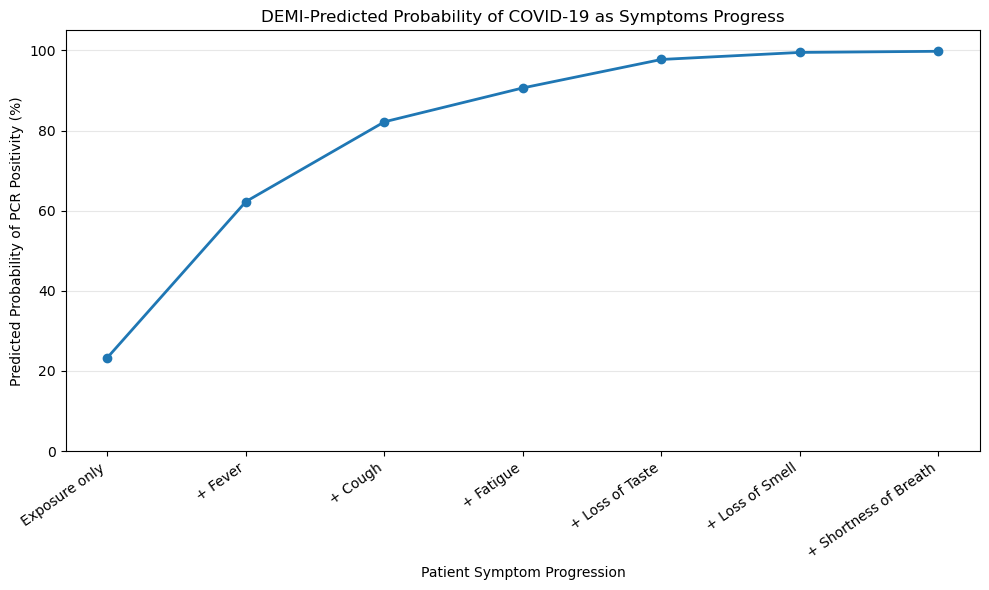

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    progression_df["Stage"],
    progression_df["Predicted Probability (%)"],
    marker="o",
    linewidth=2
)

plt.xlabel("Patient Symptom Progression")
plt.ylabel("Predicted Probability of PCR Positivity (%)")
plt.title("DEMI-Predicted Probability of COVID-19 as Symptoms Progress")

plt.ylim(0, 105)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Run the full seven-finding patient scenario
final_events = [
    concepts["COVID-19 Exposure"],
    concepts["Fever"],
    concepts["Cough"],
    concepts["Fatigue"],
    concepts["Loss of Taste"],
    concepts["Loss of Smell"],
    concepts["Shortness of Breath"]
]

# Convert concept codes to DEMI internal IDs
event_ids = [demi.get_concept_id(code) for code in final_events]
target_id = demi.get_concept_id("target_pcr_positive")

print("Event IDs:", event_ids)
print("Target ID:", target_id)

Event IDs: [122, 84, 93, 87, 112, 111, 96]
Target ID: 297


In [35]:
# Final patient scenario
final_events = [
    concepts["COVID-19 Exposure"],
    concepts["Fever"],
    concepts["Cough"],
    concepts["Fatigue"],
    concepts["Loss of Taste"],
    concepts["Loss of Smell"],
    concepts["Shortness of Breath"]
]

final_probability = demi.calculate(
    events=final_events,
    target="target_pcr_positive"
)

print(f"Final predicted probability: {final_probability * 100:.2f}%")

Falling back to internal correction-factor calculation: 'No correction_factor_table configured'


Final predicted probability: 99.77%


In [36]:
# See what detailed results DEMI stored
print(demi.last_result.keys())

dict_keys(['outcome', 'sorted_scores', 'temporal_order', 'predictors', 'K_plus', 'K_minus', 'total_or', 'T_val', 'D_val', 'lambda_l', 'prev_j', 'n_outcome_yes', 'n_outcome_no', 'pref', 'prior_odds_data', 'prior_odds', 'beta_0_prior', 'beta_0', 'correction_factor', 'correction_factor_source', 'correction_factor_row', 'n_rollup_excluded', 'n_rollup_snomed', 'n_rollup_pattern', 'platt_calibration_applied', 'platt_A', 'platt_B'])


In [37]:
print("TOTAL EFFECTS (T_val)")
display(demi.last_result["T_val"])

print("\nDIRECT EFFECTS (D_val)")
display(demi.last_result["D_val"])

TOTAL EFFECTS (T_val)


93     2.155552
122    1.396047
87     1.934611
84     2.440056
96     2.023594
111    3.585681
112    1.871802
dtype: float64


DIRECT EFFECTS (D_val)


93     0.932699
122    0.949915
87     0.633809
84     1.524757
96     1.230091
111    2.375059
112    1.871802
dtype: float64

In [38]:
print("TOTAL ODDS RATIOS")
display(demi.last_result["total_or"])

print("\nTEMPORAL ORDER")
display(demi.last_result["temporal_order"])

TOTAL ODDS RATIOS


93      8.632653
122     4.039200
87      6.921348
84     11.473684
96      7.565465
111    36.077922
112     6.500000
dtype: float64


TEMPORAL ORDER


[93, 122, 87, 84, 96, 111, 112, 297]

In [39]:
# Create mapping between DEMI internal IDs and our symptom labels

id_to_name = {}

for name, code in concepts.items():
    concept_id = demi.get_concept_id(code)
    id_to_name[concept_id] = name

print("DEMI ID → Finding")
for concept_id, name in id_to_name.items():
    print(f"{concept_id}: {name}")

DEMI ID → Finding
122: COVID-19 Exposure
84: Fever
93: Cough
87: Fatigue
112: Loss of Taste
111: Loss of Smell
96: Shortness of Breath


In [40]:
# Extract DEMI causal results

T = demi.last_result["T_val"]
D = demi.last_result["D_val"]
OR = demi.last_result["total_or"]

causal_results = []

for concept_id in T.index:
    
    causal_results.append({
        "DEMI ID": concept_id,
        "Finding": id_to_name.get(concept_id, f"Concept {concept_id}"),
        "Total Effect": T.loc[concept_id],
        "Direct Effect": D.loc[concept_id],
        "Total Odds Ratio": OR.loc[concept_id]
    })

causal_df = pd.DataFrame(causal_results)

causal_df.round(3)

,DEMI ID,Finding,Total Effect,Direct Effect,Total Odds Ratio
0,93,Cough,2.156,0.933,8.633
1,122,COVID-19 Exposure,1.396,0.950,4.039
2,87,Fatigue,1.935,0.634,6.921
3,84,Fever,2.440,1.525,11.474
4,96,Shortness of Breath,2.024,1.230,7.565
5,111,Loss of Smell,3.586,2.375,36.078
6,112,Loss of Taste,1.872,1.872,6.500


In [41]:
causal_df["Indirect Component"] = (
    causal_df["Total Effect"] -
    causal_df["Direct Effect"]
)

causal_df[
    [
        "Finding",
        "Total Effect",
        "Direct Effect",
        "Indirect Component",
        "Total Odds Ratio"
    ]
].round(3)

,Finding,Total Effect,Direct Effect,Indirect Component,Total Odds Ratio
0,Cough,2.156,0.933,1.223,8.633
1,COVID-19 Exposure,1.396,0.950,0.446,4.039
2,Fatigue,1.935,0.634,1.301,6.921
3,Fever,2.440,1.525,0.915,11.474
4,Shortness of Breath,2.024,1.230,0.794,7.565
5,Loss of Smell,3.586,2.375,1.211,36.078
6,Loss of Taste,1.872,1.872,0.000,6.500


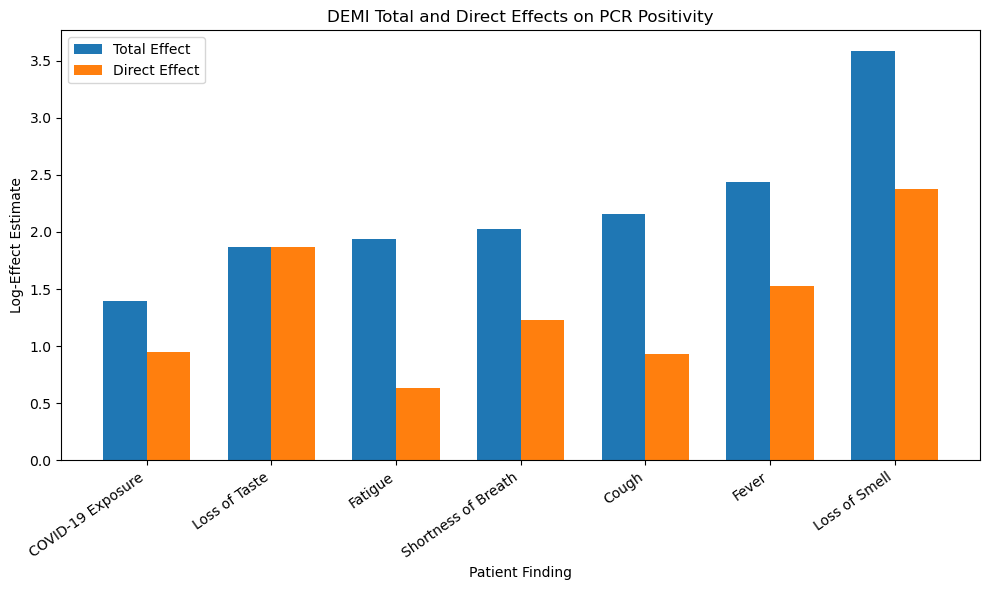

In [42]:
effect_plot = causal_df.sort_values(
    "Total Effect",
    ascending=True
)

x = np.arange(len(effect_plot))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    effect_plot["Total Effect"],
    width,
    label="Total Effect"
)

plt.bar(
    x + width/2,
    effect_plot["Direct Effect"],
    width,
    label="Direct Effect"
)

plt.xticks(
    x,
    effect_plot["Finding"],
    rotation=35,
    ha="right"
)

plt.ylabel("Log-Effect Estimate")
plt.xlabel("Patient Finding")
plt.title("DEMI Total and Direct Effects on PCR Positivity")
plt.legend()

plt.tight_layout()
plt.show()

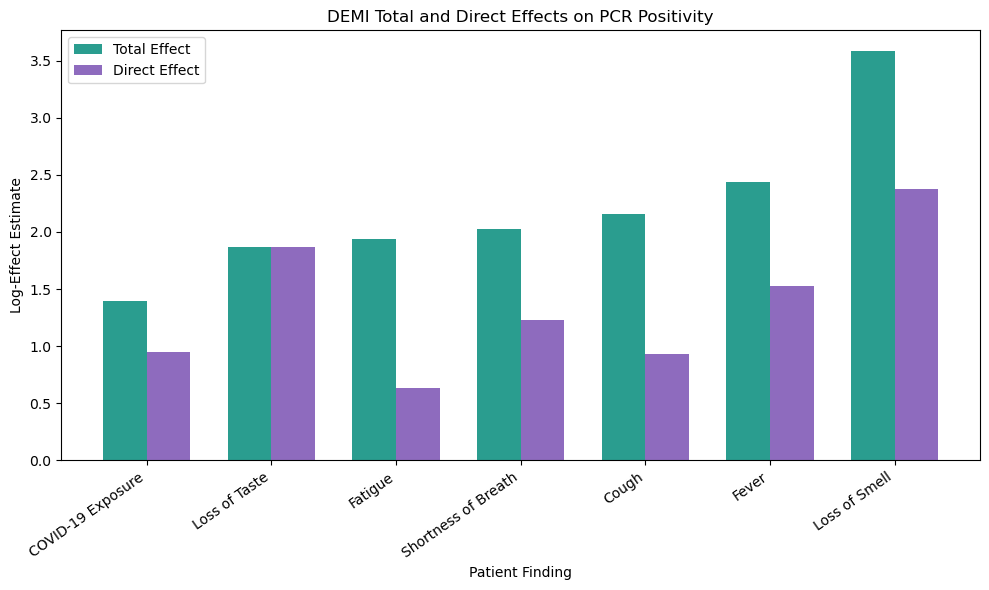

In [43]:
effect_plot = causal_df.sort_values(
    "Total Effect",
    ascending=True
)

x = np.arange(len(effect_plot))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    effect_plot["Total Effect"],
    width,
    label="Total Effect",
    color="#2A9D8F"
)

plt.bar(
    x + width/2,
    effect_plot["Direct Effect"],
    width,
    label="Direct Effect",
    color="#8E6BBE"
)

plt.xticks(
    x,
    effect_plot["Finding"],
    rotation=35,
    ha="right"
)

plt.ylabel("Log-Effect Estimate")
plt.xlabel("Patient Finding")
plt.title("DEMI Total and Direct Effects on PCR Positivity")
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Convert DEMI temporal order IDs to readable names

temporal_order = demi.last_result["temporal_order"]

named_temporal_order = []

for concept_id in temporal_order:
    if concept_id == target_id:
        name = "PCR Positive"
    else:
        name = id_to_name.get(concept_id, f"Concept {concept_id}")
    
    named_temporal_order.append(name)

print("DEMI Temporal Order:")
for i, name in enumerate(named_temporal_order, start=1):
    print(f"{i}. {name}")

DEMI Temporal Order:
1. Cough
2. COVID-19 Exposure
3. Fatigue
4. Fever
5. Shortness of Breath
6. Loss of Smell
7. Loss of Taste
8. PCR Positive


In [45]:
print(type(demi.last_result["K_plus"]))
display(demi.last_result["K_plus"])

<class 'list'>


[93, 122, 87, 84, 96, 111, 112]

In [46]:
print(type(demi.last_result["K_minus"]))
display(demi.last_result["K_minus"])

<class 'list'>


[]

In [47]:
# Inspect DEMI downstream relationships used in direct-effect calculation

lambda_l = demi.last_result["lambda_l"]
prev_j = demi.last_result["prev_j"]

for source_id, relationships in lambda_l.items():
    
    source_name = id_to_name.get(source_id, str(source_id))
    
    print(f"\n{source_name}")
    
    for target_id_rel, value in relationships.items():
        
        target_name_rel = id_to_name.get(
            target_id_rel,
            str(target_id_rel)
        )
        
        baseline = prev_j.get(target_id_rel, 0)
        adjusted_relationship = value - baseline
        
        print(
            f"  -> {target_name_rel}: "
            f"lambda={value:.3f}, "
            f"baseline={baseline:.3f}, "
            f"adjusted={adjusted_relationship:.3f}"
        )


Cough
  -> COVID-19 Exposure: lambda=0.311, baseline=0.241, adjusted=0.070
  -> Fatigue: lambda=0.503, baseline=0.230, adjusted=0.273
  -> Fever: lambda=0.298, baseline=0.122, adjusted=0.176
  -> Shortness of Breath: lambda=0.278, baseline=0.093, adjusted=0.185
  -> Loss of Smell: lambda=0.199, baseline=0.067, adjusted=0.132
  -> Loss of Taste: lambda=0.146, baseline=0.053, adjusted=0.092

COVID-19 Exposure
  -> Fatigue: lambda=0.307, baseline=0.230, adjusted=0.077
  -> Fever: lambda=0.214, baseline=0.122, adjusted=0.093
  -> Shortness of Breath: lambda=0.086, baseline=0.093, adjusted=-0.007
  -> Loss of Smell: lambda=0.136, baseline=0.067, adjusted=0.069
  -> Loss of Taste: lambda=0.107, baseline=0.053, adjusted=0.054

Fatigue
  -> Fever: lambda=0.336, baseline=0.122, adjusted=0.214
  -> Shortness of Breath: lambda=0.298, baseline=0.093, adjusted=0.205
  -> Loss of Smell: lambda=0.244, baseline=0.067, adjusted=0.178
  -> Loss of Taste: lambda=0.214, baseline=0.053, adjusted=0.161

Fe

In [48]:
import networkx as nx

In [49]:
# Build DEMI causal/dependency DAG

G = nx.DiGraph()

# Add predictor nodes
for name in concepts.keys():
    G.add_node(name)

# Add PCR outcome
G.add_node("PCR Positive")

# Add relationships among predictors
# Only retain meaningful adjusted downstream relationships

for source_id, relationships in lambda_l.items():
    
    source_name = id_to_name.get(source_id)
    
    if source_name is None:
        continue
    
    for downstream_id, lambda_value in relationships.items():
        
        downstream_name = id_to_name.get(downstream_id)
        
        if downstream_name is None:
            continue
        
        baseline = prev_j.get(downstream_id, 0)
        adjusted = lambda_value - baseline
        
        # Threshold removes very weak relationships
        if adjusted > 0.05:
            G.add_edge(
                source_name,
                downstream_name,
                weight=adjusted
            )

# Add direct-effect pathways to PCR outcome
direct_effects = demi.last_result["D_val"]

for concept_id, direct_effect in direct_effects.items():
    
    name = id_to_name.get(concept_id)
    
    if name is not None and direct_effect > 0:
        G.add_edge(
            name,
            "PCR Positive",
            weight=direct_effect
        )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 8
Edges: 27


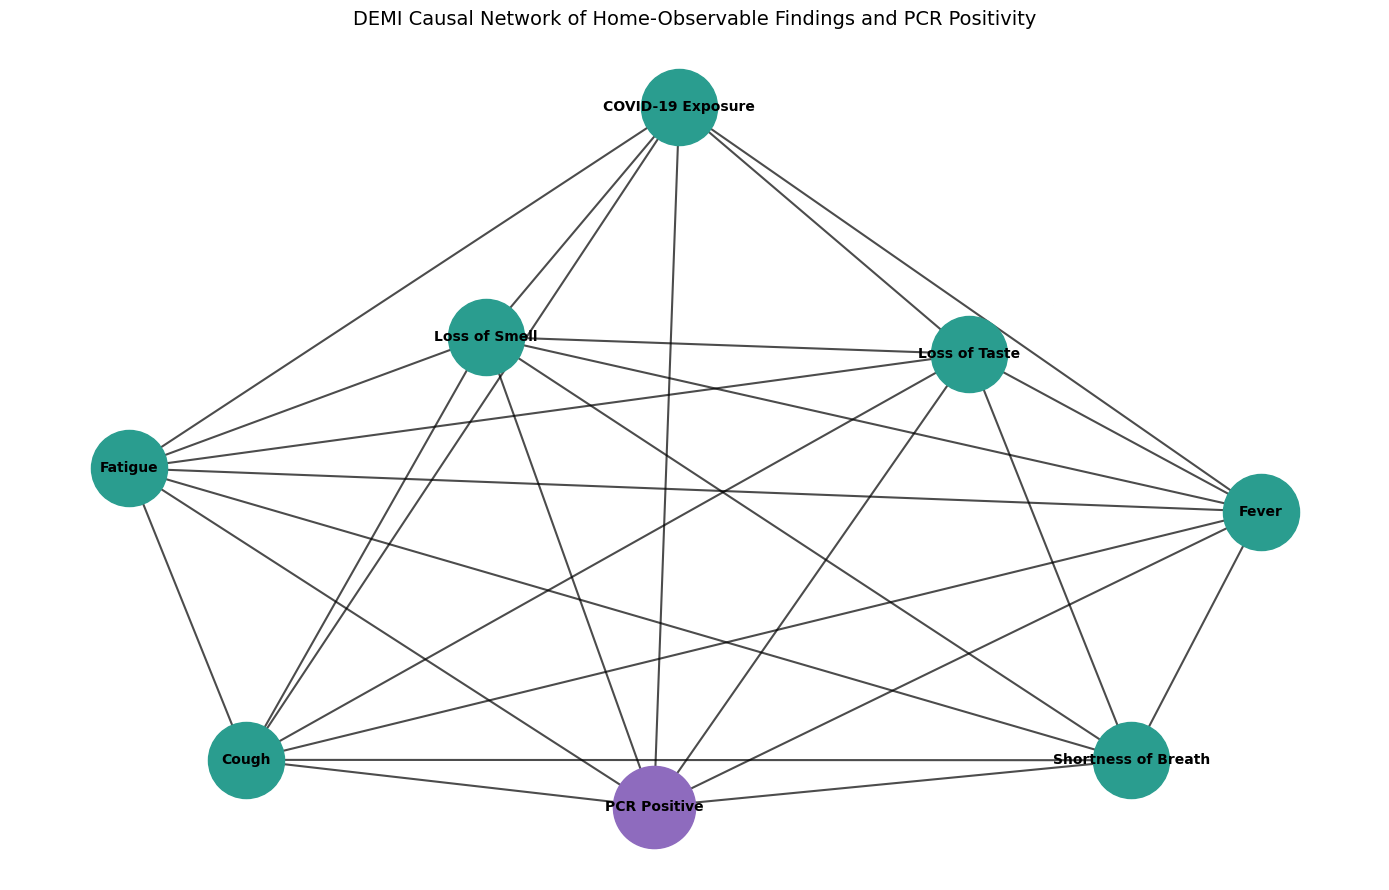

In [50]:
plt.figure(figsize=(14, 9))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

predictor_nodes = [
    node for node in G.nodes()
    if node != "PCR Positive"
]

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=predictor_nodes,
    node_size=3000,
    node_color="#2A9D8F"
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=["PCR Positive"],
    node_size=3500,
    node_color="#8E6BBE"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    width=1.5,
    alpha=0.7
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title(
    "DEMI Causal Network of Home-Observable Findings and PCR Positivity",
    fontsize=14
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [51]:
# Build Table 1: Cohort summary

total_patients = len(covid)

known_pcr = covid["PCR Test Positive"].notna().sum()
pcr_positive = (covid["PCR Test Positive"] == 1).sum()
pcr_negative = (covid["PCR Test Positive"] == 0).sum()
missing_pcr = covid["PCR Test Positive"].isna().sum()

pcr_positive_rate = (
    pcr_positive / known_pcr * 100
)

table1 = pd.DataFrame({
    "Characteristic": [
        "Total participants",
        "Participants with known PCR result",
        "PCR positive",
        "PCR negative",
        "Missing PCR result",
        "PCR positivity among known results"
    ],
    "Value": [
        total_patients,
        known_pcr,
        pcr_positive,
        pcr_negative,
        missing_pcr,
        f"{pcr_positive_rate:.2f}%"
    ]
})

table1

,Characteristic,Value
0,Total participants,822
1,Participants with known PCR result,559
2,PCR positive,58
3,PCR negative,501
4,Missing PCR result,263
5,PCR positivity among known results,10.38%


In [52]:
table3 = progression_df.copy()

table3["Predicted Probability (%)"] = (
    table3["Predicted Probability (%)"]
    .round(2)
)

table3

,Stage,Number of Findings,Predicted Probability (%)
0,Exposure only,1,23.35
1,+ Fever,2,62.28
2,+ Cough,3,82.17
3,+ Fatigue,4,90.64
4,+ Loss of Taste,5,97.73
5,+ Loss of Smell,6,99.49
6,+ Shortness of Breath,7,99.77


In [53]:
table3["Stage"] = [
    "Recent COVID-19 exposure",
    "+ Fever",
    "+ Cough",
    "+ Fatigue",
    "+ Loss of taste",
    "+ Loss of smell",
    "+ Shortness of breath"
]

table3

,Stage,Number of Findings,Predicted Probability (%)
0,Recent COVID-19 exposure,1,23.35
1,+ Fever,2,62.28
2,+ Cough,3,82.17
3,+ Fatigue,4,90.64
4,+ Loss of taste,5,97.73
5,+ Loss of smell,6,99.49
6,+ Shortness of breath,7,99.77
